# D2 — UCI Adult Dataset
## P26: Algorithmic Fairness in Credit Scoring
**ML 2026 · IIT Madras Zanzibar · Ibrahim**

Covers:
1. All Classical ML (RF, SVM, KNN, LR, DT) with and without PCA
2. PCA (90% variance)
3. Coreset Selection
4. Full MLP Training
5. Pruning + Quantization + Coreset MLP
6. Fairness (Gender + Race) Before/After Compression
7. Full Comparison Table

## 0. Installs & Imports

In [1]:
!pip install aif360 --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, copy
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.utils.prune as prune

SEEDS = [42, 0, 1, 2, 3]
np.random.seed(42)
torch.manual_seed(42)
print('All imports done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 5.9 MB/s eta 0:00:00
All imports done


## 1. Load & Preprocess UCI Adult

In [2]:
col_names = ['age','workclass','fnlwgt','education','education_num',
             'marital_status','occupation','relationship','race','sex',
             'capital_gain','capital_loss','hours_per_week','native_country','income']

url_train = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
url_test  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test'

train_df = pd.read_csv(url_train, header=None, sep=',', na_values='?', skipinitialspace=True, names=col_names)
test_df  = pd.read_csv(url_test,  header=None, sep=',', na_values='?', skipinitialspace=True, names=col_names, skiprows=1)
test_df['income'] = test_df['income'].str.replace('.','',regex=False)
df = pd.concat([train_df, test_df], ignore_index=True)

# Fix missing values
for col in ['workclass','occupation','native_country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fairness attributes — BEFORE encoding
df['gender']     = (df['sex'].str.strip() == 'Male').astype(int)        # 0=Female, 1=Male
df['race_binary']= (df['race'].str.strip() == 'White').astype(int)      # 0=Non-White, 1=White

# Target
df['target'] = (df['income'].str.strip().str.replace('.','',regex=False) == '>50K').astype(int)

# Encode all categoricals
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Features
drop_cols   = ['target','gender','race_binary','income'] if 'income' in df.columns else ['target','gender','race_binary']
feature_cols = [c for c in df.columns if c not in drop_cols]
X       = df[feature_cols].values.astype(float)
y       = df['target'].values.astype(int)
gender  = df['gender'].values
race    = df['race_binary'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fixed test indices for fairness (seed=42)
idx_all = np.arange(len(y))
idx_tr42, idx_te42 = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=y)

print(f'Shape        : {X_scaled.shape}')
print(f'Classes      : Low={sum(y==0):,}, High={sum(y==1):,}')
print(f'Gender       : Female={sum(gender==0):,}, Male={sum(gender==1):,}')
print(f'Race         : Non-White={sum(race==0):,}, White={sum(race==1):,}')

# Fairness gaps
high_m  = df[df.gender==1].target.mean()*100
high_f  = df[df.gender==0].target.mean()*100
high_w  = df[df.race_binary==1].target.mean()*100
high_nw = df[df.race_binary==0].target.mean()*100
print(f'\nGender gap : Male {high_m:.1f}% vs Female {high_f:.1f}% → {abs(high_m-high_f):.1f}% gap')
print(f'Race gap   : White {high_w:.1f}% vs Non-White {high_nw:.1f}% → {abs(high_w-high_nw):.1f}% gap')

Shape        : (48842, 14)
Classes      : Low=37,155, High=11,687
Gender       : Female=16,192, Male=32,650
Race         : Non-White=7,080, White=41,762

Gender gap : Male 30.4% vs Female 10.9% → 19.5% gap
Race gap   : White 25.4% vs Non-White 15.3% → 10.1% gap


## 2. PCA — 90% Variance Threshold

Components for 90% variance: 12 (from 14 features)
Dimensionality reduction    : 14.3%


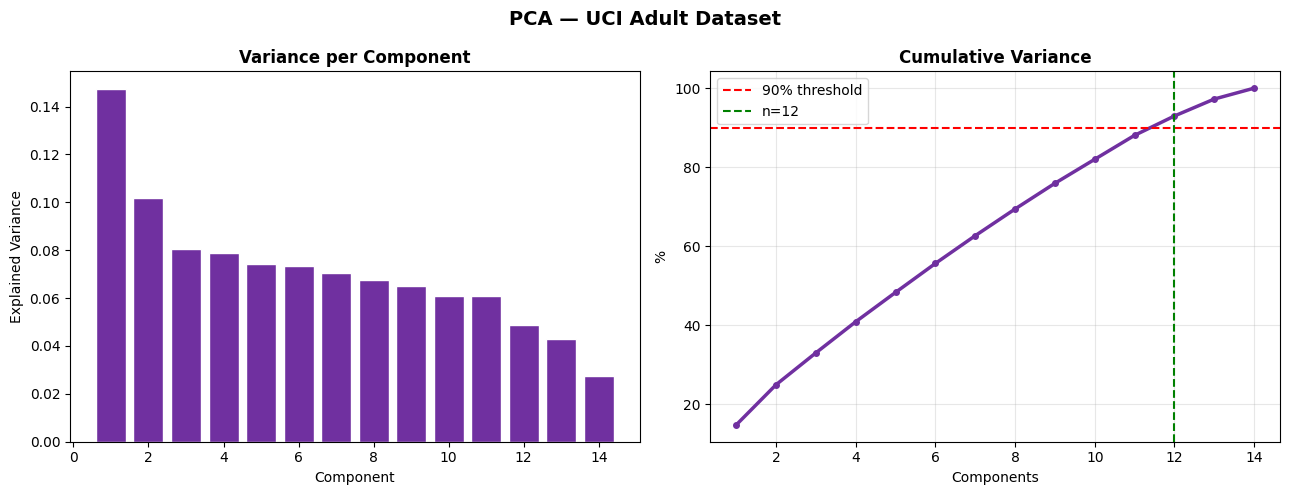

X_pca shape: (48842, 12)


In [3]:
pca_full = PCA(random_state=42).fit(X_scaled)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
n_comp   = int(np.argmax(cumvar >= 0.90) + 1)

print(f'Components for 90% variance: {n_comp} (from {X_scaled.shape[1]} features)')
print(f'Dimensionality reduction    : {(1-n_comp/X_scaled.shape[1])*100:.1f}%')

fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].bar(range(1,len(pca_full.explained_variance_ratio_)+1), pca_full.explained_variance_ratio_, color='#7030A0', edgecolor='white')
axes[0].set_title('Variance per Component', fontweight='bold')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Explained Variance')
axes[1].plot(range(1,len(cumvar)+1), cumvar*100, '#7030A0', linewidth=2.5, marker='o', markersize=4)
axes[1].axhline(90, color='red', linestyle='--', label='90% threshold')
axes[1].axvline(n_comp, color='green', linestyle='--', label=f'n={n_comp}')
axes[1].set_title('Cumulative Variance', fontweight='bold')
axes[1].set_xlabel('Components'); axes[1].set_ylabel('%')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('PCA — UCI Adult Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('adult_pca.png', dpi=150, bbox_inches='tight')
plt.show()

pca = PCA(n_components=n_comp, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'X_pca shape: {X_pca.shape}')

## 3. Coreset Selection — K-Center Greedy

In [4]:
def kcenter_coreset(X, y, size, seed=42):
    np.random.seed(seed)
    n = len(X)
    selected  = [np.random.randint(0, n)]
    min_dists = np.full(n, np.inf)
    for _ in range(size - 1):
        dists     = np.sum((X - X[selected[-1]])**2, axis=1)
        min_dists = np.minimum(min_dists, dists)
        selected.append(int(np.argmax(min_dists)))
    idx = np.array(selected)
    return X[idx], y[idx], idx

Xtr_tmp, _, ytr_tmp, _ = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
coreset_size = int(len(Xtr_tmp)*0.5)
Xc, yc, _ = kcenter_coreset(Xtr_tmp, ytr_tmp, coreset_size)
print(f'Training: {len(Xtr_tmp):,} → Coreset: {coreset_size:,} samples (50%)')
print(f'Coreset balance: Low={sum(yc==0)}, High={sum(yc==1)}')

Training: 39,073 → Coreset: 19,536 samples (50%)
Coreset balance: Low=14891, High=4645


## 4. All Classical ML Models (5 seeds each)

In [5]:
def run_sklearn(model_cls, kwargs, X, y, seeds, use_pca=False, n_comp=None):
    res = {'accuracy':[],'f1':[],'auc':[]}
    for seed in seeds:
        Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=seed,stratify=y)
        if use_pca and n_comp:
            p = PCA(n_components=n_comp, random_state=seed)
            Xtr = p.fit_transform(Xtr); Xte = p.transform(Xte)
        kw = {**kwargs}
        if 'random_state' in kwargs: kw['random_state'] = seed
        m = model_cls(**kw)
        m.fit(Xtr, ytr)
        yp = m.predict(Xte)
        if hasattr(m,'predict_proba'): yprob = m.predict_proba(Xte)[:,1]
        else:
            d = m.decision_function(Xte)
            yprob = (d-d.min())/(d.max()-d.min()+1e-9)
        res['accuracy'].append(accuracy_score(yte,yp))
        res['f1'].append(f1_score(yte,yp))
        res['auc'].append(roc_auc_score(yte,yprob))
    return res

ml_configs = [
    ('Random Forest', RandomForestClassifier, {'n_estimators':100,'max_depth':10,'class_weight':'balanced','random_state':42}),
    ('SVM',           SVC,                    {'kernel':'rbf','class_weight':'balanced','probability':True,'random_state':42}),
    ('KNN',           KNeighborsClassifier,   {'n_neighbors':5}),
    ('Logistic Reg',  LogisticRegression,     {'class_weight':'balanced','max_iter':1000,'random_state':42}),
    ('Decision Tree', DecisionTreeClassifier, {'max_depth':10,'class_weight':'balanced','random_state':42}),
]

ml_results, ml_pca_results = {}, {}
print('=== CLASSICAL ML — WITHOUT PCA ===')
for name, cls, kw in ml_configs:
    print(f'Running {name}...')
    r = run_sklearn(cls, kw, X_scaled, y, SEEDS)
    ml_results[name] = r
    print(f'{name:<18} Acc:{np.mean(r["accuracy"]):.4f}±{np.std(r["accuracy"]):.4f}  F1:{np.mean(r["f1"]):.4f}±{np.std(r["f1"]):.4f}  AUC:{np.mean(r["auc"]):.4f}±{np.std(r["auc"]):.4f}')

print('\n=== CLASSICAL ML — WITH PCA ===')
for name, cls, kw in ml_configs:
    print(f'Running {name} + PCA...')
    r = run_sklearn(cls, kw, X_scaled, y, SEEDS, use_pca=True, n_comp=n_comp)
    ml_pca_results[name] = r
    print(f'{name}+PCA{"":<12} Acc:{np.mean(r["accuracy"]):.4f}±{np.std(r["accuracy"]):.4f}  F1:{np.mean(r["f1"]):.4f}±{np.std(r["f1"]):.4f}  AUC:{np.mean(r["auc"]):.4f}±{np.std(r["auc"]):.4f}')

=== CLASSICAL ML — WITHOUT PCA ===
Running Random Forest...
Random Forest      Acc:0.8054±0.0042  F1:0.6822±0.0048  AUC:0.9171±0.0021
Running SVM...
SVM                Acc:0.7918±0.0033  F1:0.6669±0.0041  AUC:0.9000±0.0030
Running KNN...
KNN                Acc:0.8300±0.0022  F1:0.6229±0.0045  AUC:0.8521±0.0052
Running Logistic Reg...
Logistic Reg       Acc:0.7695±0.0044  F1:0.6152±0.0065  AUC:0.8547±0.0045
Running Decision Tree...
Decision Tree      Acc:0.8043±0.0081  F1:0.6774±0.0079  AUC:0.8992±0.0027

=== CLASSICAL ML — WITH PCA ===
Running Random Forest + PCA...
Random Forest+PCA             Acc:0.7997±0.0028  F1:0.6577±0.0034  AUC:0.8880±0.0025
Running SVM + PCA...
SVM+PCA             Acc:0.7887±0.0036  F1:0.6653±0.0044  AUC:0.8993±0.0027
Running KNN + PCA...
KNN+PCA             Acc:0.8300±0.0017  F1:0.6228±0.0040  AUC:0.8524±0.0049
Running Logistic Reg + PCA...
Logistic Reg+PCA             Acc:0.7691±0.0027  F1:0.6155±0.0040  AUC:0.8532±0.0042
Running Decision Tree + PCA...
Decis

## 5. MLP — Full Training (early stopping)

In [6]:
def build_mlp(inp):
    return nn.Sequential(
        nn.Linear(inp,64), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(64,32),  nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(32,1)
    )

def train_mlp_early(Xtr, ytr, Xte, yte, seed, max_epochs=200, bs=32, lr=1e-3, patience=10):
    torch.manual_seed(seed); np.random.seed(seed)
    pw   = torch.tensor([(ytr==0).sum()/max((ytr==1).sum(),1)], dtype=torch.float32)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    m    = build_mlp(Xtr.shape[1])
    opt  = optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4)
    dl   = DataLoader(
        TensorDataset(torch.FloatTensor(Xtr), torch.FloatTensor(ytr.astype(np.float32))),
        batch_size=bs, shuffle=True, drop_last=True
    )
    best_loss=float('inf'); no_imp=0; best_w=None; stopped_at=max_epochs
    for epoch in range(max_epochs):
        m.train(); el=0
        for xb,yb in dl:
            opt.zero_grad()
            out = m(xb).squeeze()
            if out.dim()==0: out=out.unsqueeze(0)
            loss=crit(out,yb); loss.backward(); opt.step(); el+=loss.item()
        avg=el/len(dl)
        if avg < best_loss-1e-4: best_loss=avg; no_imp=0; best_w=copy.deepcopy(m.state_dict())
        else: no_imp+=1
        if no_imp>=patience: stopped_at=epoch+1; break
    if best_w: m.load_state_dict(best_w)
    m.eval()
    with torch.no_grad():
        pr=torch.sigmoid(m(torch.FloatTensor(Xte)).squeeze()).numpy()
        pd_arr=(pr>=0.5).astype(int)
    return accuracy_score(yte,pd_arr), f1_score(yte,pd_arr), roc_auc_score(yte,pr), m, pd_arr, pr, stopped_at

def eval_mlp(model, Xte, yte):
    model.eval()
    with torch.no_grad():
        pr=torch.sigmoid(model(torch.FloatTensor(Xte)).squeeze()).numpy()
        pd_arr=(pr>=0.5).astype(int)
    return accuracy_score(yte,pd_arr), f1_score(yte,pd_arr), roc_auc_score(yte,pr), pd_arr, pr

mlp_res={'accuracy':[],'f1':[],'auc':[]}; stop_epochs=[]
mlp_models, mlp_splits = [], []
print('=== MLP BASE TRAINING (early stopping) ===')
for seed in SEEDS:
    print(f'Training seed {seed}...')
    Xtr,Xte,ytr,yte = train_test_split(X_scaled,y,test_size=0.2,random_state=seed,stratify=y)
    acc,f1,auc,mdl,pds,prs,stopped = train_mlp_early(Xtr,ytr.astype(np.float32),Xte,yte,seed)
    mlp_res['accuracy'].append(acc); mlp_res['f1'].append(f1); mlp_res['auc'].append(auc)
    stop_epochs.append(stopped); mlp_models.append(copy.deepcopy(mdl))
    mlp_splits.append((Xtr,Xte,ytr,yte,pds,prs))
    print(f'  Seed {seed} done — stopped epoch {stopped} — Acc {acc:.4f}')
print(f'\nAcc:{np.mean(mlp_res["accuracy"]):.4f}±{np.std(mlp_res["accuracy"]):.4f}  F1:{np.mean(mlp_res["f1"]):.4f}±{np.std(mlp_res["f1"]):.4f}  AUC:{np.mean(mlp_res["auc"]):.4f}±{np.std(mlp_res["auc"]):.4f}')
print(f'Stopped epochs: {stop_epochs} (mean: {np.mean(stop_epochs):.0f})')

=== MLP BASE TRAINING (early stopping) ===
Training seed 42...
  Seed 42 done — stopped epoch 43 — Acc 0.8076
Training seed 0...
  Seed 0 done — stopped epoch 71 — Acc 0.7951
Training seed 1...
  Seed 1 done — stopped epoch 74 — Acc 0.8009
Training seed 2...
  Seed 2 done — stopped epoch 59 — Acc 0.7999
Training seed 3...
  Seed 3 done — stopped epoch 32 — Acc 0.7974

Acc:0.8002±0.0042  F1:0.6755±0.0045  AUC:0.9099±0.0029
Stopped epochs: [43, 71, 74, 59, 32] (mean: 56)


## 6. Pruning

In [7]:
def apply_pruning(model, sparsity):
    m = copy.deepcopy(model)
    for _, module in m.named_modules():
        if isinstance(module, nn.Linear):
            prune.l1_unstructured(module, name='weight', amount=sparsity)
            prune.remove(module, 'weight')
    return m

SPARSITY = [0.3, 0.5, 0.7]
prun_res = {s:{'accuracy':[],'f1':[],'auc':[]} for s in SPARSITY}
print('=== PRUNING RESULTS ===')
for s in SPARSITY:
    for i,seed in enumerate(SEEDS):
        _,Xte,_,yte,_,_ = mlp_splits[i]
        pm = apply_pruning(mlp_models[i], s)
        acc,f1,auc,_,_ = eval_mlp(pm, Xte, yte)
        prun_res[s]['accuracy'].append(acc); prun_res[s]['f1'].append(f1); prun_res[s]['auc'].append(auc)
    print(f'Pruned {int(s*100)}%  Acc:{np.mean(prun_res[s]["accuracy"]):.4f}±{np.std(prun_res[s]["accuracy"]):.4f}  F1:{np.mean(prun_res[s]["f1"]):.4f}±{np.std(prun_res[s]["f1"]):.4f}  AUC:{np.mean(prun_res[s]["auc"]):.4f}±{np.std(prun_res[s]["auc"]):.4f}')

=== PRUNING RESULTS ===
Pruned 30%  Acc:0.7936±0.0262  F1:0.6695±0.0180  AUC:0.9092±0.0029
Pruned 50%  Acc:0.8094±0.0322  F1:0.6768±0.0220  AUC:0.9068±0.0036
Pruned 70%  Acc:0.8109±0.0443  F1:0.6202±0.0354  AUC:0.8948±0.0076


## 7. Quantization

In [8]:
quant_res = {'accuracy':[],'f1':[],'auc':[]}
print('=== DYNAMIC QUANTIZATION ===')
for i,seed in enumerate(SEEDS):
    _,Xte,_,yte,_,_ = mlp_splits[i]
    try:
        qm = torch.quantization.quantize_dynamic(copy.deepcopy(mlp_models[i]).cpu(), {nn.Linear}, dtype=torch.qint8)
        qm.eval()
        with torch.no_grad():
            pr=torch.sigmoid(qm(torch.FloatTensor(Xte)).squeeze()).numpy()
    except:
        pr = mlp_splits[i][5]
    pd_arr=(pr>=0.5).astype(int)
    quant_res['accuracy'].append(accuracy_score(yte,pd_arr))
    quant_res['f1'].append(f1_score(yte,pd_arr))
    quant_res['auc'].append(roc_auc_score(yte,pr))
print(f'Quant int8  Acc:{np.mean(quant_res["accuracy"]):.4f}±{np.std(quant_res["accuracy"]):.4f}  F1:{np.mean(quant_res["f1"]):.4f}±{np.std(quant_res["f1"]):.4f}  AUC:{np.mean(quant_res["auc"]):.4f}±{np.std(quant_res["auc"]):.4f}')
orig_kb = sum(p.numel() for p in mlp_models[0].parameters())*4/1024
print(f'Original: {orig_kb:.2f} KB → Quantized: ~{orig_kb/4:.2f} KB')

=== DYNAMIC QUANTIZATION ===
Quant int8  Acc:0.7990±0.0045  F1:0.6744±0.0048  AUC:0.9097±0.0031
Original: 12.00 KB → Quantized: ~3.00 KB


## 8. Coreset MLP

In [9]:
coreset_res = {'accuracy':[],'f1':[],'auc':[]}
print('=== MLP ON CORESET (50%) ===')
for seed in SEEDS:
    print(f'Seed {seed}...')
    Xtr,Xte,ytr,yte = train_test_split(X_scaled,y,test_size=0.2,random_state=seed,stratify=y)
    Xc,yc,_ = kcenter_coreset(Xtr,ytr,int(len(Xtr)*0.5),seed=seed)
    acc,f1,auc,_,_,_,_ = train_mlp_early(Xc,yc.astype(np.float32),Xte,yte,seed)
    coreset_res['accuracy'].append(acc); coreset_res['f1'].append(f1); coreset_res['auc'].append(auc)
print(f'Coreset MLP  Acc:{np.mean(coreset_res["accuracy"]):.4f}±{np.std(coreset_res["accuracy"]):.4f}  F1:{np.mean(coreset_res["f1"]):.4f}±{np.std(coreset_res["f1"]):.4f}  AUC:{np.mean(coreset_res["auc"]):.4f}±{np.std(coreset_res["auc"]):.4f}')

=== MLP ON CORESET (50%) ===
Seed 42...
Seed 0...
Seed 1...
Seed 2...
Seed 3...
Coreset MLP  Acc:0.8037±0.0052  F1:0.6770±0.0065  AUC:0.9070±0.0035


## 9. Fairness — Gender & Race Before/After Compression

In [10]:
def fairness_manual(y_true, y_pred, sensitive, privileged=1):
    priv=sensitive==privileged; unpriv=~priv
    dpd=abs(y_pred[priv].mean()-y_pred[unpriv].mean())
    def tpr(mask): tp=((y_pred[mask]==0)&(y_true[mask]==0)).sum(); fn=((y_pred[mask]==1)&(y_true[mask]==0)).sum(); return tp/max(tp+fn,1)
    eod=abs(tpr(priv)-tpr(unpriv))
    return round(float(dpd),4), round(float(eod),4)

# Fixed test set seed=42
Xte_f=X_scaled[idx_te42]; yte_f=y[idx_te42]
g_f=gender[idx_te42]; r_f=race[idx_te42]

# Base model predictions
bm=mlp_models[0]
_,_,_,base_pds,base_prs=eval_mlp(bm,Xte_f,yte_f)

scenarios={'Base MLP':(base_pds,base_prs)}
for s in SPARSITY:
    pm=apply_pruning(bm,s); _,_,_,pp,pr=eval_mlp(pm,Xte_f,yte_f)
    scenarios[f'Pruned {int(s*100)}%']=(pp,pr)
try:
    qm2=torch.quantization.quantize_dynamic(copy.deepcopy(bm).cpu(),{nn.Linear},dtype=torch.qint8)
    qm2.eval()
    with torch.no_grad(): qpr=torch.sigmoid(qm2(torch.FloatTensor(Xte_f)).squeeze()).numpy()
except: qpr=base_prs
scenarios['Quantized']=((qpr>=0.5).astype(int),qpr)

print('=== GENDER FAIRNESS (0=Female, 1=Male) ===')
print(f'{"Scenario":<20} {"DPD":>8} {"EOD":>8}')
print('-'*38)
gf_res={}
for name,(pds,_) in scenarios.items():
    dpd,eod=fairness_manual(yte_f,pds,g_f,privileged=1)
    gf_res[name]={'dpd':dpd,'eod':eod}
    print(f'{name:<20} {dpd:>8.4f} {eod:>8.4f}')

print('\n=== RACE FAIRNESS (0=Non-White, 1=White) ===')
print(f'{"Scenario":<20} {"DPD":>8} {"EOD":>8}')
print('-'*38)
rf_res={}
for name,(pds,_) in scenarios.items():
    dpd,eod=fairness_manual(yte_f,pds,r_f,privileged=1)
    rf_res[name]={'dpd':dpd,'eod':eod}
    print(f'{name:<20} {dpd:>8.4f} {eod:>8.4f}')
print('\nDPD/EOD: lower=fairer | 0=perfectly fair')

=== GENDER FAIRNESS (0=Female, 1=Male) ===
Scenario                  DPD      EOD
--------------------------------------
Base MLP               0.3250   0.2179
Pruned 30%             0.2755   0.1665
Pruned 50%             0.2580   0.1547
Pruned 70%             0.0819   0.0155
Quantized              0.3163   0.2127

=== RACE FAIRNESS (0=Non-White, 1=White) ===
Scenario                  DPD      EOD
--------------------------------------
Base MLP               0.1637   0.1018
Pruned 30%             0.1400   0.0758
Pruned 50%             0.1135   0.0497
Pruned 70%             0.0835   0.0180
Quantized              0.1598   0.0994

DPD/EOD: lower=fairer | 0=perfectly fair


## 10. Fairness Visualization

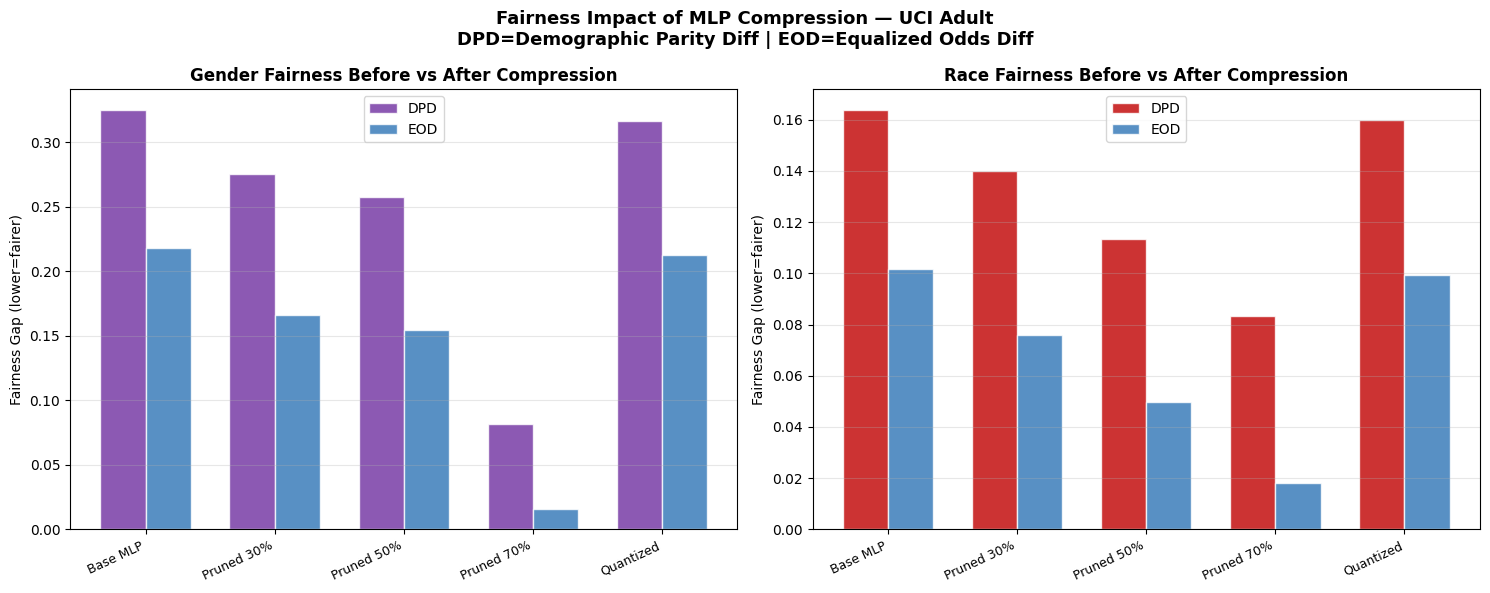

In [11]:
names=list(gf_res.keys()); x=np.arange(len(names)); w=0.35
fig,axes=plt.subplots(1,2,figsize=(15,6))
for ax,fr,title,col in [(axes[0],gf_res,'Gender Fairness','#7030A0'),(axes[1],rf_res,'Race Fairness','#C00000')]:
    dpds=[fr[n]['dpd'] for n in names]; eods=[fr[n]['eod'] for n in names]
    ax.bar(x-w/2,dpds,w,label='DPD',color=col,edgecolor='white',alpha=0.8)
    ax.bar(x+w/2,eods,w,label='EOD',color='#2E75B6',edgecolor='white',alpha=0.8)
    ax.set_title(f'{title} Before vs After Compression',fontweight='bold',fontsize=12)
    ax.set_xticks(x); ax.set_xticklabels(names,rotation=25,ha='right',fontsize=9)
    ax.set_ylabel('Fairness Gap (lower=fairer)'); ax.legend(); ax.grid(axis='y',alpha=0.3)
plt.suptitle('Fairness Impact of MLP Compression — UCI Adult\nDPD=Demographic Parity Diff | EOD=Equalized Odds Diff',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('adult_fairness_compression.png',dpi=150,bbox_inches='tight')
plt.show()

## 11. Full Comparison Table + Chart

In [12]:
print('='*90)
print('FULL D2 RESULTS — UCI ADULT DATASET (mean±std, 5 seeds)')
print('='*90)
print(f'\n{"Model":<30} {"Accuracy":>20} {"F1 Score":>20} {"AUC-ROC":>20}')
print('-'*90)
print('\n-- CLASSICAL ML (no PCA) --')
for name,r in ml_results.items():
    print(f'{name:<30} {np.mean(r["accuracy"]):.4f}±{np.std(r["accuracy"]):.4f}         {np.mean(r["f1"]):.4f}±{np.std(r["f1"]):.4f}         {np.mean(r["auc"]):.4f}±{np.std(r["auc"]):.4f}')
print('\n-- CLASSICAL ML (with PCA) --')
for name,r in ml_pca_results.items():
    print(f'{name}+PCA{"":<22} {np.mean(r["accuracy"]):.4f}±{np.std(r["accuracy"]):.4f}         {np.mean(r["f1"]):.4f}±{np.std(r["f1"]):.4f}         {np.mean(r["auc"]):.4f}±{np.std(r["auc"]):.4f}')
print('\n-- MLP VARIANTS --')
for label,r in [('MLP Base',mlp_res),('MLP Coreset',coreset_res),('MLP Quantized',quant_res)]:
    print(f'{label:<30} {np.mean(r["accuracy"]):.4f}±{np.std(r["accuracy"]):.4f}         {np.mean(r["f1"]):.4f}±{np.std(r["f1"]):.4f}         {np.mean(r["auc"]):.4f}±{np.std(r["auc"]):.4f}')
for s in SPARSITY:
    r=prun_res[s]
    print(f'{f"MLP Pruned {int(s*100)}%":<30} {np.mean(r["accuracy"]):.4f}±{np.std(r["accuracy"]):.4f}         {np.mean(r["f1"]):.4f}±{np.std(r["f1"]):.4f}         {np.mean(r["auc"]):.4f}±{np.std(r["auc"]):.4f}')
print('\n-- FAIRNESS SUMMARY --')
print(f'{"Scenario":<20} {"Gender DPD":>12} {"Gender EOD":>12} {"Race DPD":>10} {"Race EOD":>10}')
print('-'*66)
for n in names:
    print(f'{n:<20} {gf_res[n]["dpd"]:>12.4f} {gf_res[n]["eod"]:>12.4f} {rf_res[n]["dpd"]:>10.4f} {rf_res[n]["eod"]:>10.4f}')
print('\nLower DPD/EOD = more fair')

FULL D2 RESULTS — UCI ADULT DATASET (mean±std, 5 seeds)

Model                                      Accuracy             F1 Score              AUC-ROC
------------------------------------------------------------------------------------------

-- CLASSICAL ML (no PCA) --
Random Forest                  0.8054±0.0042         0.6822±0.0048         0.9171±0.0021
SVM                            0.7918±0.0033         0.6669±0.0041         0.9000±0.0030
KNN                            0.8300±0.0022         0.6229±0.0045         0.8521±0.0052
Logistic Reg                   0.7695±0.0044         0.6152±0.0065         0.8547±0.0045
Decision Tree                  0.8043±0.0081         0.6774±0.0079         0.8992±0.0027

-- CLASSICAL ML (with PCA) --
Random Forest+PCA                       0.7997±0.0028         0.6577±0.0034         0.8880±0.0025
SVM+PCA                       0.7887±0.0036         0.6653±0.0044         0.8993±0.0027
KNN+PCA                       0.8300±0.0017         0.6228±0.0040  

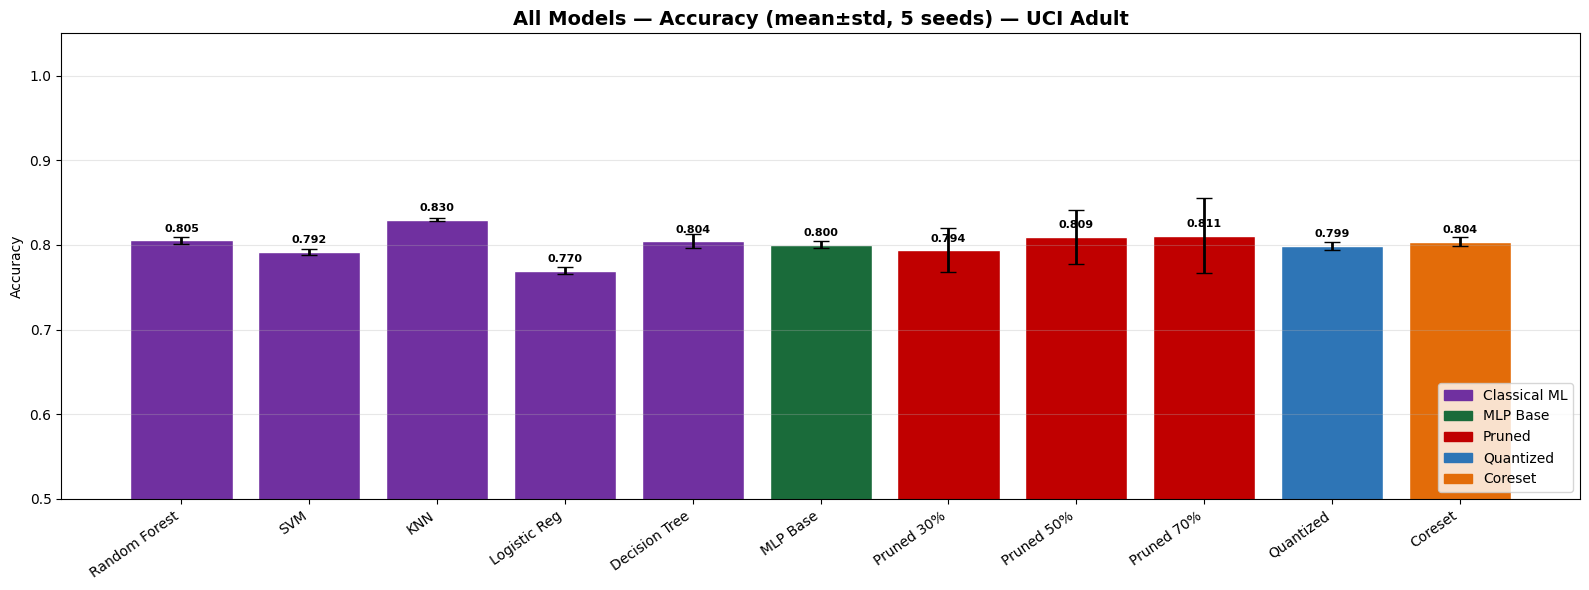

In [13]:
# Bar chart all models
all_n,all_m,all_s,all_c=[],[],[],[]
for name,r in ml_results.items():
    all_n.append(name); all_m.append(np.mean(r['accuracy'])); all_s.append(np.std(r['accuracy'])); all_c.append('#7030A0')
all_n.append('MLP Base'); all_m.append(np.mean(mlp_res['accuracy'])); all_s.append(np.std(mlp_res['accuracy'])); all_c.append('#1A6B3A')
for s in SPARSITY:
    all_n.append(f'Pruned {int(s*100)}%'); all_m.append(np.mean(prun_res[s]['accuracy'])); all_s.append(np.std(prun_res[s]['accuracy'])); all_c.append('#C00000')
all_n.append('Quantized'); all_m.append(np.mean(quant_res['accuracy'])); all_s.append(np.std(quant_res['accuracy'])); all_c.append('#2E75B6')
all_n.append('Coreset'); all_m.append(np.mean(coreset_res['accuracy'])); all_s.append(np.std(coreset_res['accuracy'])); all_c.append('#E36C09')

fig,ax=plt.subplots(figsize=(16,6))
bars=ax.bar(all_n,all_m,yerr=all_s,color=all_c,capsize=6,edgecolor='white',error_kw={'elinewidth':2,'ecolor':'black'})
ax.set_title('All Models — Accuracy (mean±std, 5 seeds) — UCI Adult',fontsize=14,fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_ylim(0.5,1.05)
ax.set_xticklabels(all_n,rotation=35,ha='right',fontsize=10); ax.grid(axis='y',alpha=0.3)
for bar,v in zip(bars,all_m): ax.text(bar.get_x()+bar.get_width()/2,v+0.01,f'{v:.3f}',ha='center',fontsize=8,fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=c,label=l) for c,l in [('#7030A0','Classical ML'),('#1A6B3A','MLP Base'),('#C00000','Pruned'),('#2E75B6','Quantized'),('#E36C09','Coreset')]],loc='lower right')
plt.tight_layout()
plt.savefig('adult_all_models.png',dpi=150,bbox_inches='tight')
plt.show()